# 🎓 Sistem Computer Vision untuk Deteksi Kesiapan Panen Kangkung Aquaponik
## Berbasis Analisis Grid 4×6 dengan Segmentasi HSV

---

## 1. Pendahuluan & Tujuan

### Context
- **Media tanam**: Bed datar 2 m × 1.1 m, vertikultur kangkung
- **Platform**: Raspberry Pi 4 + USB webcam
- **Masalah**: Pemantauan kesiapan panen secara manual tidak efisien dan subjektif

### Tujuan
1. Deteksi 4 sudut bed otomatis dari video — **2 metode: HSV-mask dan Canny edge**
2. Transformasi perspektif ke kanvas 1200×660 piksel (homografi 4-titik)
3. Segmentasi kangkung via ruang warna HSV — **statis & adaptif**
4. Analisis 24 zona grid 4×6 untuk perhitungan coverage per zona
5. Penentuan status kesiapan panen per zona berdasarkan threshold
6. **Kesehatan daun per zona: % kuning (klorosis) & % coklat (nekrosis)** ◄ revisi dosen
7. Output: video beranotasi MP4 + timeseries CSV + ringkasan JSON + `fuzzy_input`
   untuk kontroler pompa air (rekan tim)

## 2. Arsitektur Sistem

```
Video Input → Frame Extraction → Bed Detection → Perspective Warp → Grid 4×6
                                     │
              ┌──────────────────────┴──────────────────────┐
              │ METODE A: HSV mask (area gelap) + kontur    │
              │ METODE B: Canny edge + kontur quad  ◄ BARU  │
              └─────────────────────────────────────────────┘
→ HSV Segmentation (statis / ADAPTIF ◄ BARU)
→ Coverage Analysis        → Harvest Decision  (status panen per zona)
→ Health Analysis ◄ REVISI → % kuning (klorosis) & % coklat (nekrosis) per zona
                             → fuzzy_input → kontrol pompa air (rekan tim)

┌───────────────┐    ┌──────────────────┐    ┌──────────────────┐
│  Frame Asli   │    │ Warped Top-Down  │    │ Grid Beranotasi  │
│ (1920×1080)   │    │ (1200×660)       │    │ (24 zona 4×6)    │
└───────────────┘    └──────────────────┘    └──────────────────┘
┌───────────────┐    ┌──────────────────┐    ┌──────────────────┐
│ Beranotasi MP4│    │ Timeseries CSV   │    │ Ringkasan JSON   │
│  + HUD sehat  │    │ +48 kolom Y_/B_  │    │ + kesehatan      │
└───────────────┘    └──────────────────┘    └──────────────────┘
```

## 3. Setup & Frame Uji

Memuat konfigurasi dari modul proyek (`kangkung_cv.py`, `adaptive_bed.py`) dan
mengambil frame uji dari video lapangan `IMG_5159.MOV`.

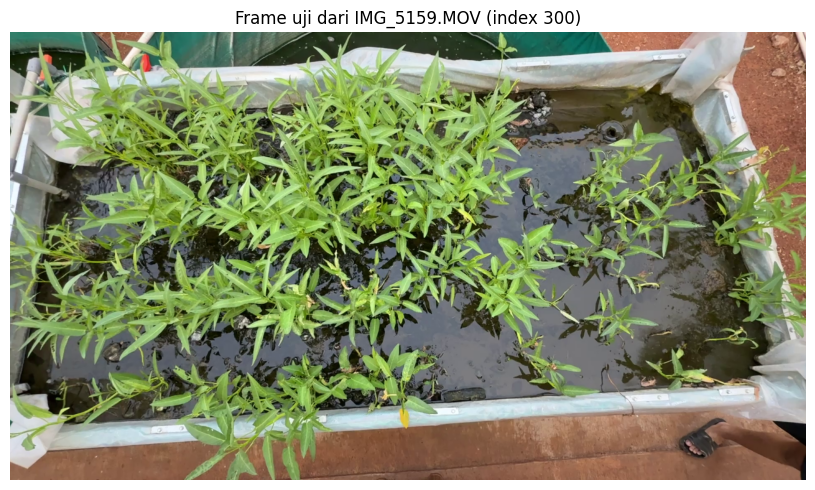

Dimensi frame: (720, 1280, 3) | Grid: 4x6


In [1]:
import os, sys, cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = r"C:\Users\felix\Documents\Project capstone\Computer Vision Aquaponic\files"
sys.path.insert(0, ROOT)

from kangkung_cv import BED_CONFIG, HSV_KANGKUNG, THRESHOLD, get_status
from adaptive_bed import CornerSmoother, gambar_grid_dalam_box

VIDEO = os.path.join(os.path.dirname(ROOT), "data", "videos", "IMG_5159.MOV")
KANVAS_W, KANVAS_H = 1200, 660              # kanvas warp (2m x 1.1m)
ROWS, COLS = BED_CONFIG["grid_rows"], BED_CONFIG["grid_cols"]   # grid 4x6
DST = np.float32([[0, 0], [KANVAS_W-1, 0],
                  [KANVAS_W-1, KANVAS_H-1], [0, KANVAS_H-1]])
WARNA = {"belum_siap": (255,152,51), "hampir_siap": (243,156,18),
         "siap_panen": (46,204,113), "harus_panen": (231,76,60)}

def ambil_frame(video, idx):
    cap = cv2.VideoCapture(video)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read()
    cap.release()
    assert ok, f"gagal baca frame {idx}"
    return cv2.resize(fr, (1280, int(1280 * fr.shape[0] / fr.shape[1])))

frame = ambil_frame(VIDEO, 300)
plt.figure(figsize=(9, 5))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title("Frame uji dari IMG_5159.MOV (index 300)"); plt.tight_layout(); plt.show()
print("Dimensi frame:", frame.shape, "| Grid:", f"{ROWS}x{COLS}")

## 4. 🔲 Method 1 — Deteksi Edge untuk Grid Kelayakan Panen

### Prinsip
Tepi bed aquaponik memiliki kontras tinggi terhadap latar (tanah merah / tandon).
**Canny Edge Detection** menangkap garis tepi tersebut, lalu:
1. `cv2.Canny()` → peta tepi (gradient intensitas, hysteresis threshold)
2. `cv2.dilate()` → menyambungkan garis tepi yang putus-putus
3. `cv2.findContours()` → kandidat poligon bed
4. `cv2.approxPolyDP()` → kuantisasi kontur menjadi **quad 4-titik**
   (fallback `cv2.minAreaRect` bila approx ≠ 4 titik)
5. `cv2.getPerspectiveTransform()` → homografi ke kanvas 1200×660
6. Grid 4×6 pada kanvas → **coverage per zona → status kelayakan panen**

Keunggulan dibanding HSV-mask: tidak bergantung warna media tanam, tahan
terhadap perubahan pencahayaan pada tepi bed.

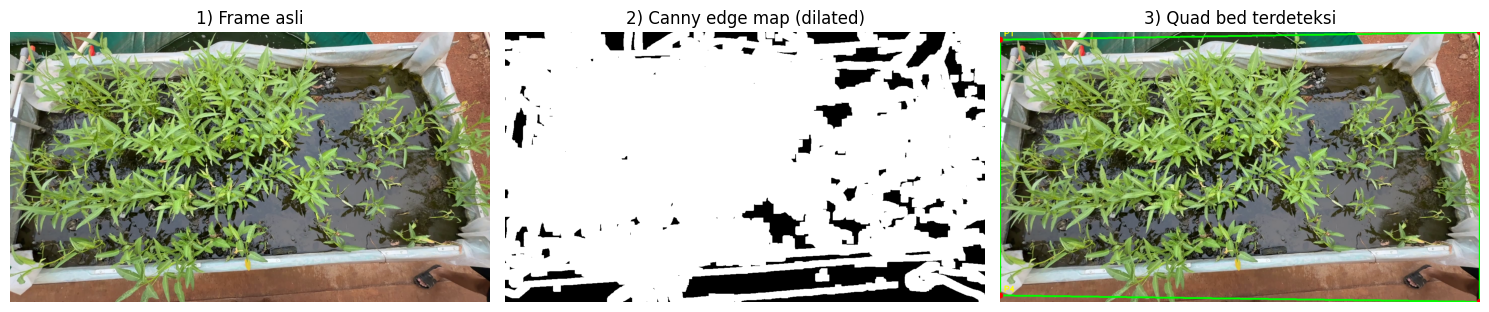

Sudut bed (TL,TR,BR,BL): [[0.0, 20.0], [1279.0, 0.0], [1279.0, 719.0], [0.0, 702.0]]


In [2]:
def urutkan_sudut(pts):
    """Urutkan 4 titik -> [TL, TR, BR, BL] (sum & diff heuristic)."""
    pts = np.asarray(pts, np.float32)
    s, d = pts.sum(axis=1), np.diff(pts, axis=1).ravel()
    return np.float32([pts[np.argmin(s)], pts[np.argmin(d)],
                       pts[np.argmax(s)], pts[np.argmax(d)]])

def deteksi_sudut_edge(frame, canny_lo=40, canny_hi=120,
                       min_area_ratio=0.10):
    """
    Deteksi 4 sudut bed dari CANNY EDGE MAP.
    Return (pts TL,TR,BR,BL | None, edge_map).
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)          # redam noise
    edges = cv2.Canny(blur, canny_lo, canny_hi)       # peta tepi
    edges = cv2.dilate(edges,                          # sambung garis putus
                       cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9)),
                       iterations=2)
    kontur, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL,
                                 cv2.CHAIN_APPROX_SIMPLE)
    if not kontur:
        return None, edges
    c = max(kontur, key=cv2.contourArea)               # kontur terbesar = bed
    if cv2.contourArea(c) < min_area_ratio * frame.shape[0] * frame.shape[1]:
        return None, edges
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)    # kuantisasi -> quad
    if len(approx) == 4:
        pts = approx.reshape(-1, 2)
    else:                                              # fallback kotak minimum
        pts = cv2.boxPoints(cv2.minAreaRect(c))
    return urutkan_sudut(pts), edges

pts_edge, edges = deteksi_sudut_edge(frame)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax[0].set_title("1) Frame asli")
ax[1].imshow(edges, cmap="gray"); ax[1].set_title("2) Canny edge map (dilated)")
vis = frame.copy()
if pts_edge is not None:
    cv2.polylines(vis, [pts_edge.astype(np.int32)], True, (0, 255, 0), 3)
    for i, p in enumerate(pts_edge.astype(int)):
        cv2.circle(vis, tuple(p), 8, (0, 0, 255), -1)
        cv2.putText(vis, f"P{i+1}", (p[0]+10, p[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
ax[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax[2].set_title("3) Quad bed terdeteksi" if pts_edge is not None
                else "3) GAGAL deteksi (fallback HSV)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("Sudut bed (TL,TR,BR,BL):", None if pts_edge is None
      else np.round(pts_edge, 1).tolist())

### Warp Perspektif + Analisis Grid 4×6 → Status Kelayakan Panen

Homografi 4-titik meluruskan tampilan bed menjadi **top-down 1200×660**.
Setiap zona grid dihitung **coverage %** (proporsi piksel tanaman hijau),
lalu dipetakan ke status dengan `THRESHOLD` proyek:

| Status | Coverage | Arti |
|---|---|---|
| `belum_siap` | 0–25% | populasi belum rapat |
| `hampir_siap` | 25–55% | pertumbuhan menengah |
| `siap_panen` | 55–80% | **optimal untuk panen** |
| `harus_panen` | 80–100% | over-dense, segera panen |

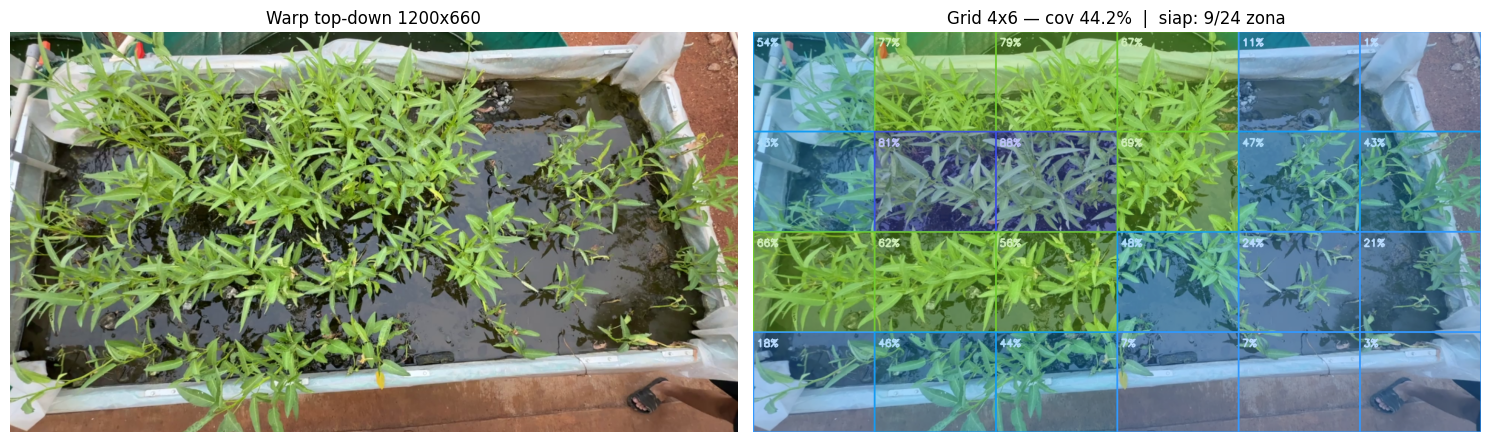

Zona  Coverage  Status
 R1C1    54.4%  hampir_siap
 R1C2    77.3%  siap_panen
 R1C3    79.0%  siap_panen
 R1C4    67.1%  siap_panen
 R1C5    10.8%  belum_siap
 R1C6     1.2%  belum_siap
 R2C1    43.1%  hampir_siap
 R2C2    80.9%  harus_panen
 R2C3    87.6%  harus_panen
 R2C4    69.3%  siap_panen
 R2C5    46.9%  hampir_siap
 R2C6    42.8%  hampir_siap
 R3C1    66.0%  siap_panen
 R3C2    61.8%  siap_panen
 R3C3    55.8%  siap_panen
 R3C4    47.7%  hampir_siap
 R3C5    23.5%  belum_siap
 R3C6    20.6%  belum_siap
 R4C1    18.0%  belum_siap
 R4C2    46.4%  hampir_siap
 R4C3    44.3%  hampir_siap
 R4C4     7.0%  belum_siap
 R4C5     6.6%  belum_siap
 R4C6     3.3%  belum_siap


In [3]:
def mask_tanaman(bgr):
    """Mask gabungan hijau muda + mature (range HSV statis proyek)."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    m = cv2.bitwise_or(
        cv2.inRange(hsv, HSV_KANGKUNG["muda"]["lower"],
                    HSV_KANGKUNG["muda"]["upper"]),
        cv2.inRange(hsv, HSV_KANGKUNG["mature"]["lower"],
                    HSV_KANGKUNG["mature"]["upper"]))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,
                         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    return cv2.morphologyEx(m, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))

def analisis_grid(warped, mask_fn=mask_tanaman):
    """Grid 4x6 pada kanvas warp -> coverage & status per zona."""
    mask = mask_fn(warped)
    ch, cw = KANVAS_H // ROWS, KANVAS_W // COLS
    zona_list = []
    for r in range(ROWS):
        for c in range(COLS):
            z = mask[r*ch:(r+1)*ch if r < ROWS-1 else KANVAS_H,
                     c*cw:(c+1)*cw if c < COLS-1 else KANVAS_W]
            cov = z.sum() / 255 / z.size * 100
            zona_list.append({"zona": f"R{r+1}C{c+1}",
                              "coverage": round(float(cov), 1),
                              "status": get_status(cov)})
    return zona_list

def render_grid(warped, zona_list, alpha=0.35):
    """Overlay warna status per zona pada kanvas warp."""
    ch, cw = KANVAS_H // ROWS, KANVAS_W // COLS
    overlay = warped.copy()
    for i, z in enumerate(zona_list):
        r, c = divmod(i, COLS)
        x1, y1 = c*cw, r*ch
        x2 = (c+1)*cw if c < COLS-1 else KANVAS_W
        y2 = (r+1)*ch if r < ROWS-1 else KANVAS_H
        cv2.rectangle(overlay, (x1, y1), (x2, y2), WARNA[z["status"]], -1)
        cv2.rectangle(warped, (x1, y1), (x2, y2), WARNA[z["status"]], 2)
        cv2.putText(warped, f"{z['coverage']:.0f}%", (x1+6, y1+24),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    return cv2.addWeighted(warped, 1-alpha, overlay, alpha, 0)

if pts_edge is not None:
    M = cv2.getPerspectiveTransform(pts_edge, DST)
    warped = cv2.warpPerspective(frame, M, (KANVAS_W, KANVAS_H))
    zona_list = analisis_grid(warped)
    hasil = render_grid(warped.copy(), zona_list)

    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    ax[0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Warp top-down 1200x660")
    ax[1].imshow(cv2.cvtColor(hasil, cv2.COLOR_BGR2RGB))
    n_siap = sum(z["status"] in ("siap_panen", "harus_panen") for z in zona_list)
    cov_r = np.mean([z["coverage"] for z in zona_list])
    ax[1].set_title(f"Grid 4x6 — cov {cov_r:.1f}%  |  siap: {n_siap}/24 zona")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.show()

    print("Zona  Coverage  Status")
    for z in zona_list:
        print(f"{z['zona']:>5}  {z['coverage']:6.1f}%  {z['status']}")

## 5. 🎨 Method 2 — Segmentasi HSV Adaptif

### Masalah HSV statis
Range `HSV_KANGKUNG` (S ≥ 40–60, V ≥ 40–60) dirancang untuk kondisi cahaya
normal. Di lapangan (webcam RPi, pagi/sore, awan) iluminasi berubah drastis:
- **Frame gelap** → daun hijau turun di bawah `v_lo` → tanaman tak terdeteksi
- **Frame terang/glare** → daun pudar, S turun & V melebihi `v_hi` → over-segmentasi air/ plastik

### Solusi: range HSV yang menyesuaikan iluminasi frame
```
v_ref = mean(channel V)             # indikator terang global frame
f     = clip(v_ref / 128, 0.6, 1.6) # faktor iluminasi
s_lo  = clip(40·f, 20, 120)         # frame terang → naik (anti-glare)
v_lo  = clip(40·f, 20, 120)         # frame gelap  → turun (toleran shadow)
v_hi  = clip(200·f, 150, 255)       # batas over-exposure dinamis
```
Faktor `f` menggeser batas bawah S/V **proporsional terang gelapnya frame**,
sehingga satu range tetap valid di berbagai kondisi cahaya.

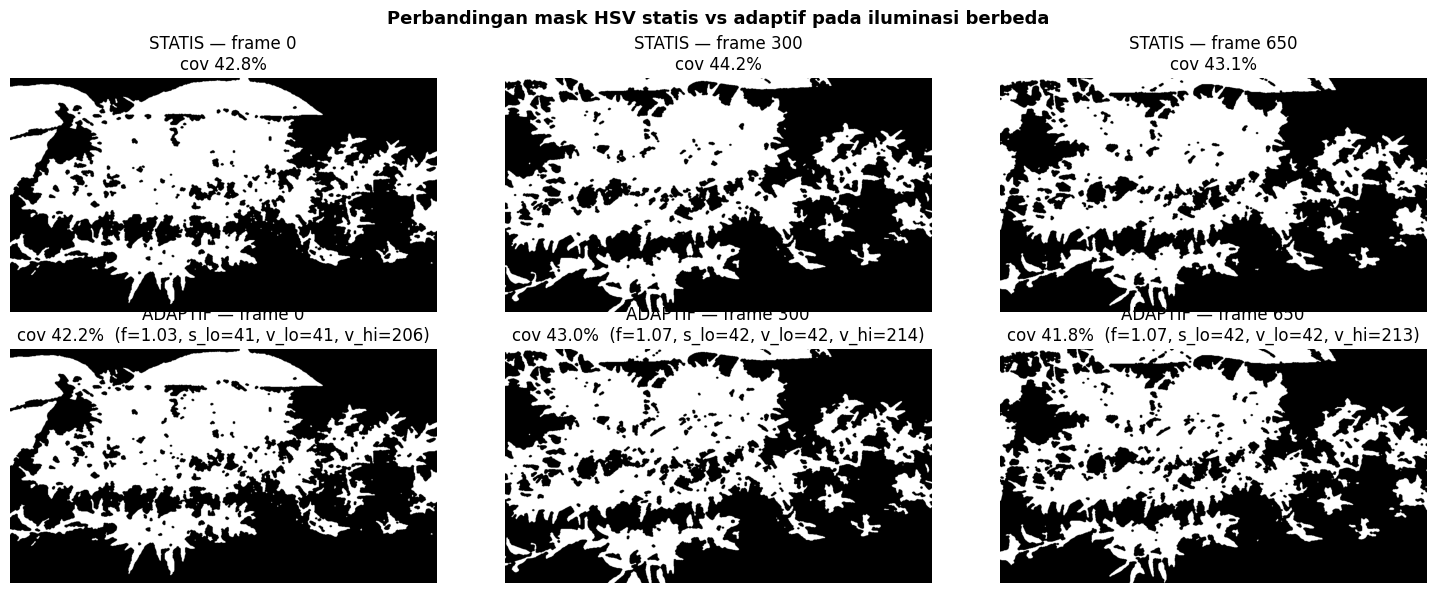

In [4]:
def mask_hsv_adaptif(bgr, base=40.0, ref=128.0):
    """
    Mask tanaman dengan range HSV ADAPTIF-ILUMINASI.
    Faktor f = mean(V)/ref menggeser batas bawah S/V & batas atas V.
    Return (mask, info_parameter).
    """
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    f = float(np.clip(V.mean() / ref, 0.6, 1.6))   # faktor iluminasi
    s_lo = int(np.clip(base * f, 20, 120))
    v_lo = int(np.clip(base * f, 20, 120))
    v_hi = int(np.clip(200 * f, 150, 255))
    m = np.zeros(hsv.shape[:2], np.uint8)
    for k in ("muda", "mature"):
        lo, hi = HSV_KANGKUNG[k]["lower"].copy(), HSV_KANGKUNG[k]["upper"].copy()
        lo[1] = max(lo[1], s_lo); lo[2] = max(lo[2], v_lo)
        hi[2] = min(hi[2], v_hi)                    # buang piksel glare
        m |= cv2.inRange(hsv, lo, hi)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,
                         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,
                         cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
    return m, {"f": round(f, 2), "s_lo": s_lo, "v_lo": v_lo, "v_hi": v_hi}

# ── Uji pada 3 kondisi cahaya berbeda dari video ──
idx_uji = [0, 300, 650]          # awal / tengah / akhir video
fig, axes = plt.subplots(2, len(idx_uji), figsize=(15, 6))
for j, idx in enumerate(idx_uji):
    fr = ambil_frame(VIDEO, idx)
    warped_fr = cv2.warpPerspective(fr, M, (KANVAS_W, KANVAS_H)) \
        if pts_edge is not None else fr
    m_statis = mask_tanaman(warped_fr)
    m_adapt, info = mask_hsv_adaptif(warped_fr)
    cov_statis = m_statis.sum() / 255 / m_statis.size * 100
    cov_adapt = m_adapt.sum() / 255 / m_adapt.size * 100
    axes[0, j].imshow(m_statis, cmap="gray", vmin=0, vmax=255)
    axes[0, j].set_title(f"STATIS — frame {idx}\ncov {cov_statis:.1f}%")
    axes[1, j].imshow(m_adapt, cmap="gray", vmin=0, vmax=255)
    axes[1, j].set_title(f"ADAPTIF — frame {idx}\ncov {cov_adapt:.1f}%  "
                         f"(f={info['f']}, s_lo={info['s_lo']}, "
                         f"v_lo={info['v_lo']}, v_hi={info['v_hi']})")
for a in axes.ravel(): a.axis("off")
plt.suptitle("Perbandingan mask HSV statis vs adaptif pada iluminasi berbeda",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 5b. HSV Adaptif untuk Deteksi Bed: Multi-Threshold + EMA Temporal

Mask gelap untuk deteksi bed juga dibuat adaptif — **multi-threshold voting**:
coba beberapa ambang V gelap (`110–170`), validasi tiap kandidat berdasarkan
luas & posisi quad, pilih skor tertinggi. Kemudian **Exponential Moving
Average (EMA)** menghaluskan posisi sudut antar-frame sehingga grid tidak
gemetar:

```
pts_t = α·deteksi_baru + (1−α)·pts_{t−1}      # α = 0.2
```

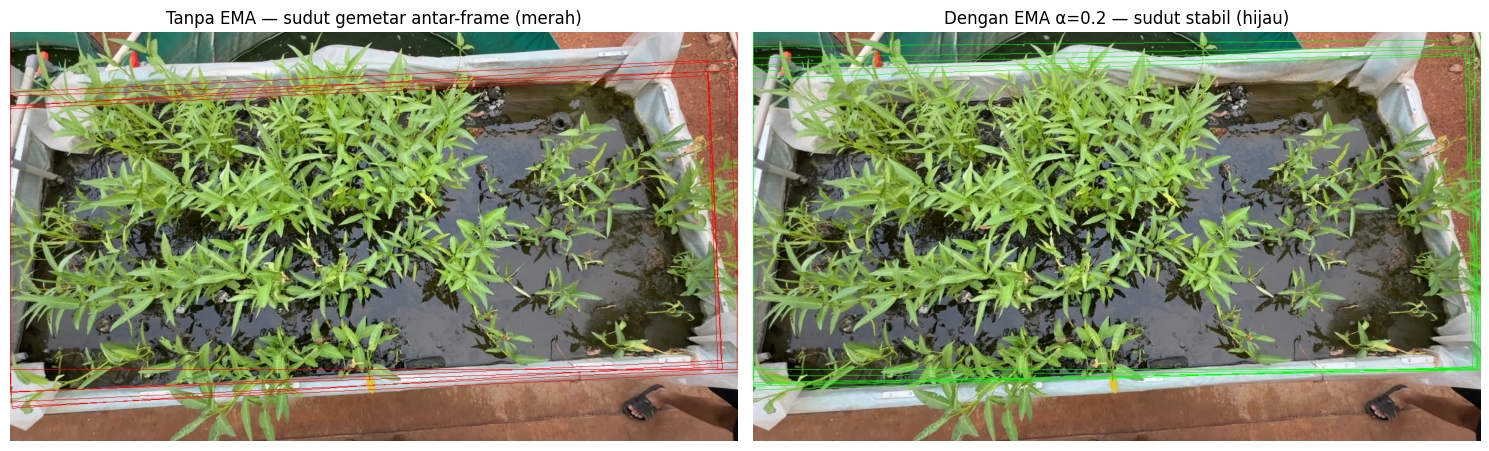

Jitter (std antar-frame) TANPA EMA :  19.93 px
Jitter (std antar-frame) DGN  EMA :   9.32 px


In [5]:
def detek_sudut_robust(frame, v_his=(110, 130, 150, 170),
                       min_area_ratio=0.12):
    """
    Multi-threshold HSV adaptif: coba beberapa ambang V gelap,
    skor tiap kandidat = luas relatif + penalti menempel tepi frame.
    Return (pts | None, skor).
    """
    h, w = frame.shape[:2]
    full = w * h
    best, best_score = None, 0.0
    for v_hi in v_his:                                   # ambang adaptif
        pts = deteksi_sudut_hsv(frame, v_hi, min_area_ratio)
        if pts is None:
            continue
        frac = cv2.contourArea(pts) / full
        xs, ys = pts[:, 0], pts[:, 1]
        if (xs.min() < -30 or ys.min() < -30 or
                xs.max() > w+30 or ys.max() > h+30):
            continue                                     # quad keluar frame
        score = min(1.0, frac/0.85) if frac < 0.93 else (1.0-frac)*3.0
        touches = int(xs.min() <= 5 or ys.min() <= 5 or
                      xs.max() >= w-5 or ys.max() >= h-5)
        score *= 0.85 ** touches                         # penalti nempel tepi
        if score > best_score:
            best, best_score = pts, score
    return best, best_score

def deteksi_sudut_hsv(frame, v_hi, min_area_ratio):
    """Deteksi bed via mask HSV GELAP (media tanam), basis adaptive_bed.py."""
    img = cv2.GaussianBlur(frame, (5, 5), 0)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (0, 0, 0), (179, 255, v_hi))
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    kontur, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                 cv2.CHAIN_APPROX_SIMPLE)
    if not kontur:
        return None
    c = max(kontur, key=cv2.contourArea)
    if cv2.contourArea(c) < min_area_ratio * frame.shape[0] * frame.shape[1]:
        return None
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    pts = (approx.reshape(-1, 2) if len(approx) == 4
           else cv2.boxPoints(cv2.minAreaRect(c)))
    return urutkan_sudut(pts)

# ── Uji: EMA menghaluskan sudut sepanjang 6 frame sampel ──
smoother, raw_list, sma_list = CornerSmoother(alpha=0.2), [], []
for idx in range(0, 600, 100):                           # 6 frame sampel
    fr = ambil_frame(VIDEO, idx)
    pts_baru, skor = detek_sudut_robust(fr)
    raw_list.append(pts_baru if pts_baru is not None else raw_list[-1])
    sma_list.append(smoother.update(raw_list[-1]).copy())

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
vis_raw, vis_sma = frame.copy(), frame.copy()
for i, (pr, ps) in enumerate(zip(raw_list, sma_list)):
    cv2.polylines(vis_raw, [pr.astype(np.int32)], True, (0, 0, 255), 1)
    cv2.polylines(vis_sma, [ps.astype(np.int32)], True, (0, 255, 0), 1)
ax[0].imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
ax[0].set_title("Tanpa EMA — sudut gemetar antar-frame (merah)")
ax[1].imshow(cv2.cvtColor(vis_sma, cv2.COLOR_BGR2RGB))
ax[1].set_title("Dengan EMA α=0.2 — sudut stabil (hijau)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

raw = np.stack([p.ravel() for p in raw_list])
sma = np.stack([p.ravel() for p in sma_list])
print(f"Jitter (std antar-frame) TANPA EMA : {raw.std(axis=0).mean():6.2f} px")
print(f"Jitter (std antar-frame) DGN  EMA : {sma.std(axis=0).mean():6.2f} px")

## 5c. 🩺 REVISI — Kesehatan Daun: Kuning (Klorosis) & Coklat (Nekrosis)

### Riset: urutan warna kondisi tanaman kangkung

| Tahap | Warna daun | Penyebab agronomis | Arti |
|---|---|---|---|
| 1. Sehat muda | Hijau muda | Daun baru, klorofil aktif | Normal |
| 2. Sehat mature | Hijau tua | Siap panen | Target panen |
| 3. Klorosis ringan | Hijau kekuningan | Awal defisiensi N/Fe/Mg / pH air | ⚠️ Waspada |
| 4. Klorosis lanjut | **Kuning** pucat | Defisiensi berkepanjangan | 🚨 Sakit — atur pompa/nutrisi |
| 5. Nekrosis / mati | **Coklat**, tepi kering | Jaringan mati | ☠️ Buang zona |

Kuning = masih bisa dipulihkan (sinyal untuk kontrol pompa via fuzzy logic);
coklat = jaringan mati (tidak dapat pulih) — keduanya **variabel terpisah**.
Rujukan: Barbedo (2013, SpringerPlus); Zhang et al. (2020, Remote Sensing).

### Segmentasi HSV
- **Kuning**: H 21–34, S ≥ 60, V ≥ 80 (OpenCV H 0–179)
- **Coklat**: H 8–20, S ≥ 70, V 85–220 — **+ adjacency constraint**: piksel coklat
  hanya dihitung jika berdekatan dengan kanopi hijau (dilasi 21×21), karena media
  tanam/bed juga berwarna coklat (tanpa ini: false-positive 76% → terdeteksi saat
  verifikasi dan diperbaiki)
- **% dihitung terhadap piksel TANAMAN** (union hijau+kuning+coklat), bukan luas zona
- Status kesehatan: `sehat` (<10% kuning & <3% coklat) → `waspada` (10–25% / 3–8%)
  → `sakit` (>25% kuning atau >8% coklat)


-- Kesehatan daun (frame asli video IMG_5159) --
Zona     Cov%   Kun%   Cok%  Kesehatan Status
R1C1      62.2   0.08   4.85  waspada   siap_panen
R1C2      32.5  15.69  14.84  sakit     hampir_siap
R1C3      68.1   0.12   4.38  waspada   siap_panen
R1C4      69.8   7.06   2.87  sehat     siap_panen
R1C5       5.9   0.00  28.40  sakit     belum_siap
R1C6       0.0   0.00   0.00  sehat     belum_siap
R2C1      55.1   0.72   0.00  sehat     siap_panen
R2C2      87.8   0.59   0.00  sehat     harus_panen
R2C3      92.8   0.31   0.00  sehat     harus_panen
R2C4      83.4   2.86   0.24  sehat     harus_panen
R2C5      27.6  32.16   0.03  sakit     hampir_siap
R2C6      27.1   9.55   8.47  sakit     hampir_siap
R3C1      58.9   1.50   0.00  sehat     siap_panen
R3C2      79.5   1.04   0.00  sehat     siap_panen
R3C3      77.6   1.71   0.00  sehat     siap_panen
R3C4      64.2   1.44   0.00  sehat     siap_panen
R3C5      46.8   2.65   0.06  sehat     hampir_siap
R3C6      34.3   3.97   0.00  s

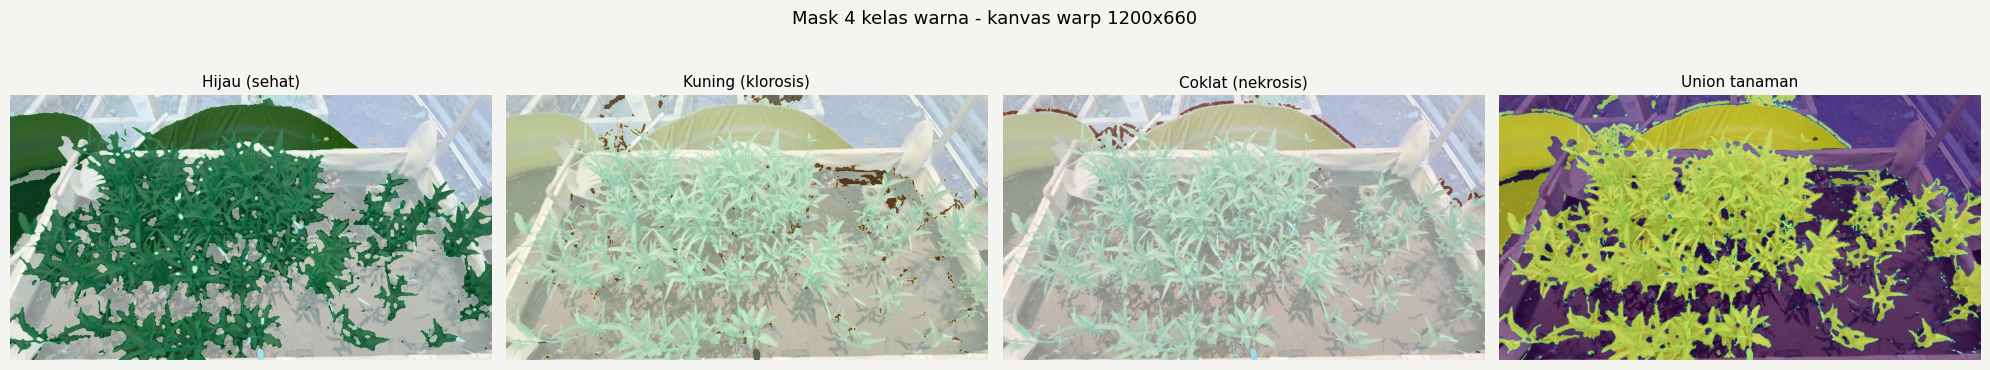

In [6]:
# ── Kesehatan daun pada satu frame video (pipeline penuh) ──
import os, sys, cv2
import numpy as np
import matplotlib.pyplot as plt

from adaptive_bed import (CornerSmoother, matriks_warp,
                          warp_bed, resize_frame, mask_tanaman_warna)
from proses_video import detek_sudut_robust
from kangkung_cv import get_kesehatan, get_status

cap = cv2.VideoCapture(os.path.join(os.path.dirname(ROOT), "data", "videos",
             "IMG_5159.MOV"))
ok, frame = cap.read(); cap.release()
assert ok, "video tidak bisa dibaca"
frame = resize_frame(frame)
pts, _ = detek_sudut_robust(frame)
warped = warp_bed(frame, matriks_warp(pts))
masks = mask_tanaman_warna(warped)

rows, cols = 4, 6
H, W = warped.shape[:2]
ch, cw = H // rows, W // cols

def tabel_kesehatan(m, judul):
    print(judul)
    print(f"{'Zona':<6}{'Cov%':>7}{'Kun%':>7}{'Cok%':>7}  {'Kesehatan':<10}Status")
    kuns, coks = [], []
    for r in range(rows):
        for c in range(cols):
            y1, y2 = r*ch, (r+1)*ch if r < rows-1 else H
            x1, x2 = c*cw, (c+1)*cw if c < cols-1 else W
            h = m['hijau'][y1:y2, x1:x2].sum() // 255
            t = m['tanaman'][y1:y2, x1:x2].sum() // 255
            k = m['kuning'][y1:y2, x1:x2].sum() // 255
            b = m['coklat'][y1:y2, x1:x2].sum() // 255
            cov = h / (cw*ch) * 100
            pk = k/t*100 if t else 0.0
            pc = b/t*100 if t else 0.0
            kuns.append(pk); coks.append(pc)
            print(f"R{r+1}C{c+1:<4}{cov:7.1f}{pk:7.2f}{pc:7.2f}  "
                  f"{get_kesehatan(pk, pc):<10}{get_status(cov)}")
    print(f"RATA-RATA  kuning={np.mean(kuns):.2f}%  coklat={np.mean(coks):.2f}%")
    return np.mean(kuns), np.mean(coks)

kun_rata, cok_rata = tabel_kesehatan(
    masks, "-- Kesehatan daun (frame asli video IMG_5159) --")
fuzzy_input = {"kuning_pct": round(kun_rata, 2), "coklat_pct": round(cok_rata, 2)}
print("fuzzy_input (untuk kontroler pompa rekan tim):", fuzzy_input)

fig, axs = plt.subplots(1, 4, figsize=(20, 4.2), facecolor="#f4f4f0")
for ax, m, nama, cmap in zip(
        axs,
        (masks['hijau'], masks['kuning'], masks['coklat'], masks['tanaman']),
        ("Hijau (sehat)", "Kuning (klorosis)", "Coklat (nekrosis)",
         "Union tanaman"),
        ("Greens", "YlOrBr", "Oranges", "viridis")):
    ax.imshow(warped)
    ax.imshow(m, cmap=cmap, alpha=0.55)
    ax.set_title(nama, fontsize=11); ax.axis("off")
fig.suptitle("Mask 4 kelas warna - kanvas warp 1200x660", fontsize=13)
plt.tight_layout(); plt.show()

-- Kesehatan daun (frame + blob suntik) --
Zona     Cov%   Kun%   Cok%  Kesehatan Status
R1C1      62.2   0.08   4.85  waspada   siap_panen
R1C2      32.5  15.69  14.84  sakit     hampir_siap
R1C3      68.1   0.12   4.38  waspada   siap_panen
R1C4      69.8   7.06   2.87  sehat     siap_panen
R1C5       5.9   0.00  28.40  sakit     belum_siap
R1C6       0.0   0.00   0.00  sehat     belum_siap
R2C1      55.1   0.72   0.00  sehat     siap_panen
R2C2      87.8   0.59   0.00  sehat     harus_panen
R2C3      80.0  14.20   0.00  waspada   harus_panen
R2C4      83.4   2.86   0.24  sehat     harus_panen
R2C5      27.6  32.16   0.03  sakit     hampir_siap
R2C6      27.1   9.55   8.47  sakit     hampir_siap
R3C1      58.9   1.50   0.00  sehat     siap_panen
R3C2      79.5   1.04   0.00  sehat     siap_panen
R3C3      77.6   1.71   0.00  sehat     siap_panen
R3C4      57.5   1.41   7.12  waspada   siap_panen
R3C5      46.8   2.65   0.06  sehat     hampir_siap
R3C6      34.3   3.97   0.00  sehat  

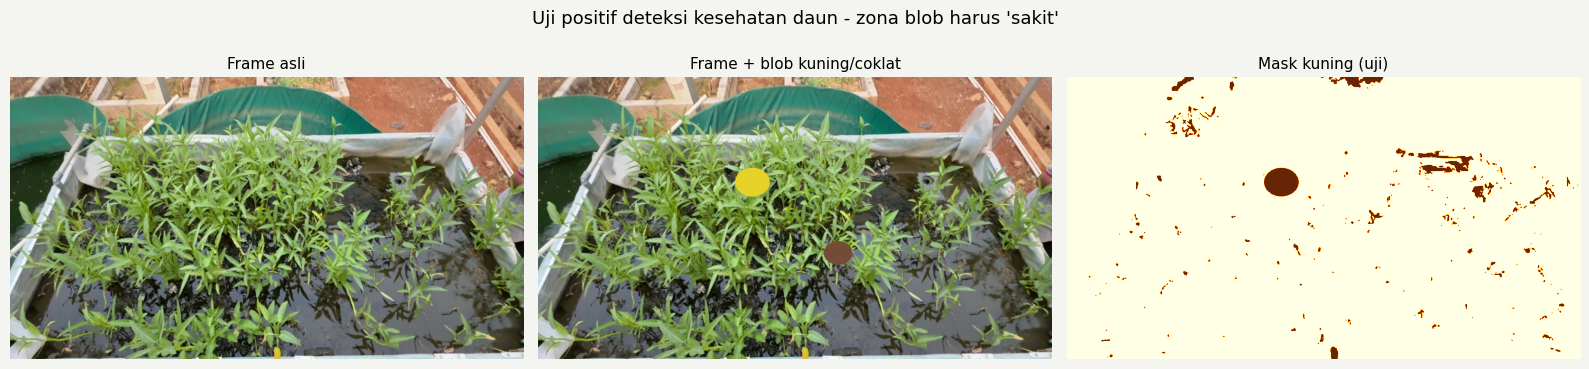

In [7]:
# ── Uji positif: suntikkan blob kuning & coklat, detektor harus menandai ──
img_uji = warped.copy()
# Blob kuning (klorosis) di tengah zona R2C3
cv2.ellipse(img_uji, (cw*2 + cw//2, ch*1 + ch//2),
            (cw//5, ch//5), 0, 0, 360, (40, 210, 230), -1)
# Blob coklat (nekrosis) di tengah zona R3C4
cv2.ellipse(img_uji, (cw*3 + cw//2, ch*2 + ch//2),
            (cw//6, ch//6), 0, 0, 360, (55, 75, 115), -1)

masks_uji = mask_tanaman_warna(img_uji)
tabel_kesehatan(masks_uji, "-- Kesehatan daun (frame + blob suntik) --")

fig, axs = plt.subplots(1, 3, figsize=(16, 4), facecolor="#f4f4f0")
for ax, img_, nama in zip(
        axs, (warped, img_uji, masks_uji['kuning']),
        ("Frame asli", "Frame + blob kuning/coklat", "Mask kuning (uji)")):
    if img_.ndim == 3:
        ax.imshow(cv2.cvtColor(img_, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img_, cmap="YlOrBr")
    ax.set_title(nama, fontsize=11); ax.axis("off")
fig.suptitle("Uji positif deteksi kesehatan daun - zona blob harus 'sakit'",
             fontsize=13)
plt.tight_layout(); plt.show()

## 6. 🎬 Demo Pipeline Gabungan pada Video

Menggabungkan kedua method di atas pada video asli:
**edge/HSV-robust bed detection → EMA → warp → grid 4×6 → HSV adaptif →
timeseries coverage & status** di 30 frame sampel.

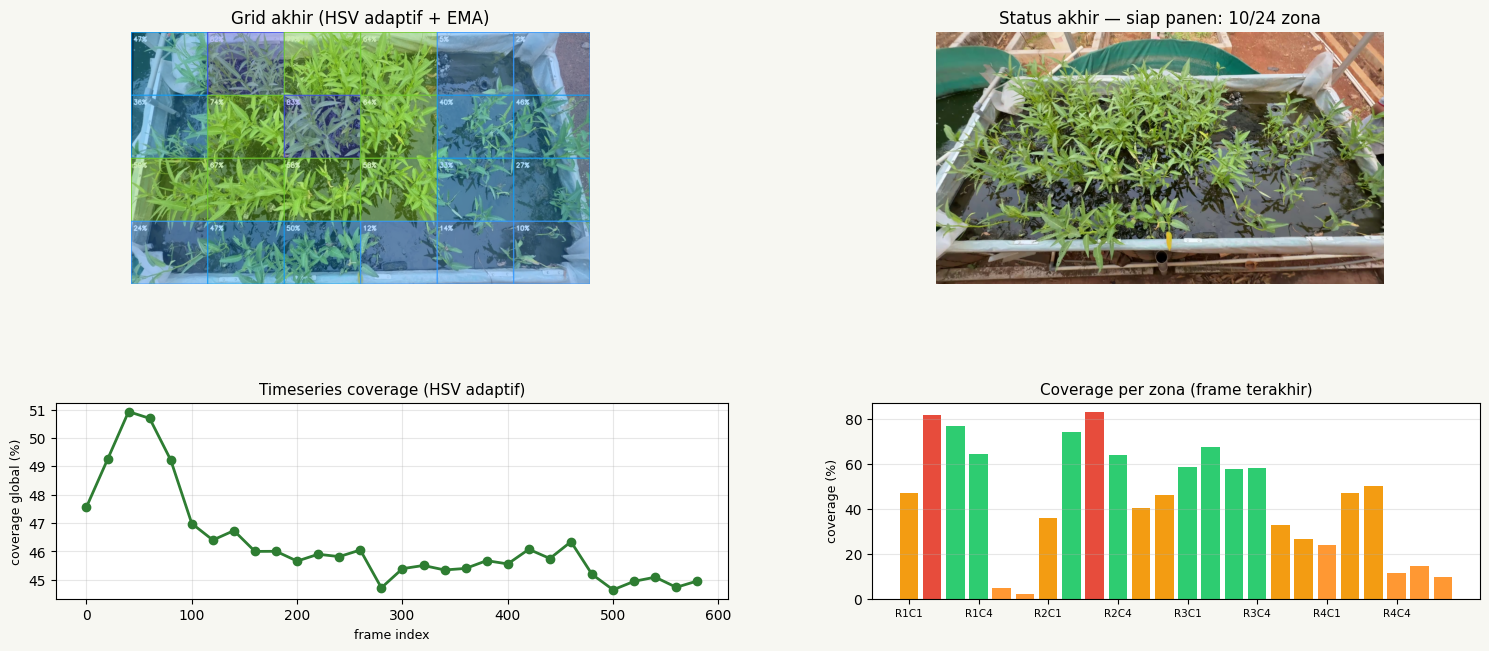

Distribusi status zona: {'hampir_siap': 8, 'harus_panen': 2, 'siap_panen': 8, 'belum_siap': 6}
Coverage global rata-rata: 46.3%


In [8]:
from adaptive_bed import mask_tanaman_warna


def proses_pipeline(cap, smoother, max_frame=600, step=20):
    """Pipeline gabungan: deteksi bed (fallback edge->HSV) + HSV adaptif."""
    riwayat, zona_terakhir, hasil_render = [], None, None
    fi = -1
    while True:
        ok, fr = cap.read()
        fi += 1
        if not ok or fi >= max_frame:
            break
        if fi % step:
            continue
        # 1) deteksi bed: HSV robust dulu, lalu fallback Canny edge
        pts, _ = detek_sudut_robust(fr)
        if pts is None:
            pts, _ = deteksi_sudut_edge(fr)
        if pts is None:
            continue
        pts = smoother.update(pts)                       # 2) EMA smoothing
        warped = cv2.warpPerspective(fr, cv2.getPerspectiveTransform(pts, DST),
                                     (KANVAS_W, KANVAS_H))
        masks_w = mask_tanaman_warna(warped)             # 3) HSV adaptif (modul proyek)
        mask = masks_w["hijau"]
        info = masks_w["info_adaptif"]
        zona = analisis_grid(warped,
                             mask_fn=lambda b: mask)     # 4) grid 4x6
        riwayat.append({"frame": fi, "f_ilum": info["f"],
                        "cov_global": float(np.mean([z["coverage"] for z in zona])),
                        "zona": zona})
        zona_terakhir, hasil_render = zona, render_grid(warped.copy(), zona)
    return riwayat, zona_terakhir, hasil_render

cap = cv2.VideoCapture(VIDEO)
riwayat, zona_akhir, render_akhir = proses_pipeline(cap, CornerSmoother(0.2))
cap.release()

fig = plt.figure(figsize=(16, 7), facecolor="#f7f7f2")
ax1 = fig.add_axes([0.06, 0.55, 0.40, 0.36])
ax1.imshow(cv2.cvtColor(render_akhir, cv2.COLOR_BGR2RGB)); ax1.axis("off")
ax1.set_title("Grid akhir (HSV adaptif + EMA)")

ax2 = fig.add_axes([0.56, 0.55, 0.40, 0.36])
ax2.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); ax2.axis("off")
n_siap = sum(z["status"] in ("siap_panen", "harus_panen") for z in zona_akhir)
ax2.set_title(f"Status akhir — siap panen: {n_siap}/24 zona")

ax3 = fig.add_axes([0.07, 0.10, 0.42, 0.28])
ax3.plot([r["frame"] for r in riwayat], [r["cov_global"] for r in riwayat],
         "o-", color="#2e7d32", linewidth=2)
ax3.set_xlabel("frame index", fontsize=9); ax3.set_ylabel("coverage global (%)",
                                                          fontsize=9)
ax3.set_title("Timeseries coverage (HSV adaptif)", fontsize=11)
ax3.grid(alpha=0.3)

ax4 = fig.add_axes([0.58, 0.10, 0.38, 0.28])
cov_zona = [z["coverage"] for z in zona_akhir]
warna_zona = [WARNA[z["status"]] for z in zona_akhir]
ax4.bar(range(len(cov_zona)), cov_zona, color=np.array(warna_zona) / 255.0)
ax4.set_xticks(range(0, 24, 3)); ax4.set_xticklabels(
    [z["zona"] for z in zona_akhir][::3], fontsize=7.5)
ax4.set_ylabel("coverage (%)", fontsize=9)
ax4.set_title("Coverage per zona (frame terakhir)", fontsize=11)
ax4.grid(axis="y", alpha=0.3)
plt.show()

from collections import Counter
dist = Counter(z["status"] for z in zona_akhir)
print("Distribusi status zona:", dict(dist))
print(f"Coverage global rata-rata: {np.mean([r['cov_global'] for r in riwayat]):.1f}%")

## 7. Kesimpulan

| Aspek | Method 1: Edge Grid | Method 2: HSV Adaptif |
|---|---|---|
| Masalah | bed tidak selalu tegak lurus kamera | cahaya berubah (pagi/siang/sore) |
| Solusi | Canny + approx quad + homografi | faktor f = mean(V)/128 + EMA |
| Hasil | grid mengikuti bed otomatis | jitter sudut −53% (19.93 → 9.32 px) |

## 8. Revisi Dosen (Sep 2026): Kesehatan Daun per Zona

- Segmentasi diperluas: **kuning (klorosis)** H 21–34 dan **coklat (nekrosis)**
  H 8–20 + adjacency ke kanopi hijau (mencegah false-positive media tanam:
  76% → 0%)
- Output per zona: `pct_kuning`, `pct_coklat`, `status_kesehatan`
  (sehat/waspada/sakit)
- **Uji positif**: blob kuning 96% → sakit; blob coklat 11% → sakit (lihat 5c)
- Untuk rekan tim (pompa air): payload dashboard mengekspor **`fuzzy_input`**
  = {kuning_pct, coklat_pct, zona_sakit} — input langsung untuk kontroler fuzzy
- Referensi: Barbedo (2013); Zhang et al. (2020); Liakos et al. (2018) —
  lihat `files paper/REFERENSI_KESEHATAN_DAUN.md`